#### Assignment 2: Building a Machine Learning Pipeline

Course: MBAI 5310G-001 AI Programming

Dataset: Financial Customer Investment Risk Dataset

Goal: Predict whether a customer has high investment risk


#### Step 1: Understanding the Machine Learning Problem

Before writing any code, I need to understand the business problem and the data.

The business problem is that financial companies want to know which customers are likely to take high investment risks. This information helps financial advisors give better advice and offer the right investment products to the right customers.

What I am trying to predict:
I want to predict the column called High Investment Risk. The two possible values are Yes and No.

Type of machine learning problem:
This is a supervised binary classification problem. Supervised means I already have labelled data where the correct answer is known. Binary means the output has only two possible classes which are Yes and No.

Features available in the dataset:

1. Age: the age of the customer in years
2. Employment Status: whether the customer is full time, part time, retired, student or self employed
3. Annual Income: how much money the customer earns per year
4. Investment Experience Years: how many years the customer has been investing
5. Portfolio Value: the total value of the customer current investments
6. Risk Tolerance: how the customer describes their own risk tolerance as low, medium or high
7. Number of Investment Products: how many investment products the customer holds
8. Market Volatility Concern: a score showing how concerned the customer is about market changes
9. Financial Literacy Score: a score measuring how well the customer understands financial topics
10. Advisor Contacted: whether the customer has contacted a financial advisor
11. Previous Investment Loss: whether the customer has experienced a loss before


In [69]:
# Importing pandas for data manipulation
import pandas as pd

# Importing Path for handling file paths
from pathlib import Path

# Storing the file name as a string
file_name = "data/financial_customer_investment_risk_dataset.csv"

# Creating a Path object from the file name
data_path = Path(file_name)

# Printing the path to confirm it
print("Dataset path:", data_path)

# Checking whether the file exists
print("File exists:", data_path.exists())

# Loading the CSV file into a DataFrame
df = pd.read_csv(data_path)

# Confirming the dataset was loaded
print("Dataset loaded successfully!")

# Showing the first five rows
df.head()

Dataset path: data\financial_customer_investment_risk_dataset.csv
File exists: True
Dataset loaded successfully!


,Customer_ID,Age,Employment_Status,Annual_Income,Investment_Experience_Years,Portfolio_Value,Risk_Tolerance,Number_of_Investment_Products,Market_Volatility_Concern,Financial_Literacy_Score,Advisor_Contacted,Previous_Investment_Loss,High_Investment_Risk
0,1,35.0,Full-time,61257.0,18,350954.0,High,5,3,9,Yes,No,No
1,2,63.0,Retired,189284.0,18,239184.0,High,9,3,3,Yes,No,No
2,3,55.0,Part-time,36010.0,13,38681.0,Low,2,2,6,No,No,No
3,4,43.0,Part-time,46379.0,3,265566.0,Medium,11,2,5,Yes,No,No
4,5,39.0,Self-employed,195809.0,19,208719.0,Medium,9,3,10,No,Yes,No


#### Step 2: Data Preparation and Initial Inspection

In this step I inspect the dataset to understand its structure before doing any cleaning or modelling.

I check how many rows and columns the dataset has, what the column names are, what data types each column uses, whether any values are missing, and whether any rows are duplicated.


In [70]:
# Printing the shape section title
print("Dataset shape:")

# Showing the number of rows and columns
print(df.shape)

# Printing the column names title
print("\nColumn names:")

# Showing all column names as a list
print(df.columns.tolist())

# Printing the first rows title
print("\nFirst five rows:")

# Displaying the first five rows
display(df.head())

Dataset shape:
(387, 13)

Column names:
['Customer_ID', 'Age', 'Employment_Status', 'Annual_Income', 'Investment_Experience_Years', 'Portfolio_Value', 'Risk_Tolerance', 'Number_of_Investment_Products', 'Market_Volatility_Concern', 'Financial_Literacy_Score', 'Advisor_Contacted', 'Previous_Investment_Loss', 'High_Investment_Risk']

First five rows:


,Customer_ID,Age,Employment_Status,Annual_Income,Investment_Experience_Years,Portfolio_Value,Risk_Tolerance,Number_of_Investment_Products,Market_Volatility_Concern,Financial_Literacy_Score,Advisor_Contacted,Previous_Investment_Loss,High_Investment_Risk
0,1,35.0,Full-time,61257.0,18,350954.0,High,5,3,9,Yes,No,No
1,2,63.0,Retired,189284.0,18,239184.0,High,9,3,3,Yes,No,No
2,3,55.0,Part-time,36010.0,13,38681.0,Low,2,2,6,No,No,No
3,4,43.0,Part-time,46379.0,3,265566.0,Medium,11,2,5,Yes,No,No
4,5,39.0,Self-employed,195809.0,19,208719.0,Medium,9,3,10,No,Yes,No


In [71]:
# Printing the info section title
print("Dataset information:")

# Showing column names, non-null counts and data types
df.info()

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 387 entries, 0 to 386
Data columns (total 13 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Customer_ID                    387 non-null    int64  
 1   Age                            380 non-null    float64
 2   Employment_Status              380 non-null    object 
 3   Annual_Income                  380 non-null    float64
 4   Investment_Experience_Years    387 non-null    int64  
 5   Portfolio_Value                380 non-null    float64
 6   Risk_Tolerance                 380 non-null    object 
 7   Number_of_Investment_Products  387 non-null    int64  
 8   Market_Volatility_Concern      387 non-null    int64  
 9   Financial_Literacy_Score       387 non-null    int64  
 10  Advisor_Contacted              380 non-null    object 
 11  Previous_Investment_Loss       387 non-null    object 
 12  High_Investment_Risk         

In [72]:
# Printing the data types section title
print("Data types of each column:")

# Showing the data type of each column
print(df.dtypes)

Data types of each column:
Customer_ID                        int64
Age                              float64
Employment_Status                 object
Annual_Income                    float64
Investment_Experience_Years        int64
Portfolio_Value                  float64
Risk_Tolerance                    object
Number_of_Investment_Products      int64
Market_Volatility_Concern          int64
Financial_Literacy_Score           int64
Advisor_Contacted                 object
Previous_Investment_Loss          object
High_Investment_Risk              object
dtype: object


In [73]:
# Printing the missing values section title
print("Missing values in each column:")

# Counting missing values in each column
print(df.isnull().sum())

Missing values in each column:
Customer_ID                      0
Age                              7
Employment_Status                7
Annual_Income                    7
Investment_Experience_Years      0
Portfolio_Value                  7
Risk_Tolerance                   7
Number_of_Investment_Products    0
Market_Volatility_Concern        0
Financial_Literacy_Score         0
Advisor_Contacted                7
Previous_Investment_Loss         0
High_Investment_Risk             0
dtype: int64


In [74]:
# Printing the duplicates section title
print("Number of duplicate rows:")

# Counting how many duplicate rows exist
print(df.duplicated().sum())

Number of duplicate rows:
7


In [75]:
# Defining the target column name
target_column = "High_Investment_Risk"

# Printing the target column title
print("Target column:")

# Printing the name of the target column
print(target_column)

# Printing the value counts title
print("\nTarget value counts:")

# Counting how many Yes and No values exist in the target column
print(df[target_column].value_counts())

Target column:
High_Investment_Risk

Target value counts:
High_Investment_Risk
No     367
Yes     20
Name: count, dtype: int64


In [76]:
# Creating a list of all feature columns
feature_columns = [
    "Age",
    "Employment_Status",
    "Annual_Income",
    "Investment_Experience_Years",
    "Portfolio_Value",
    "Risk_Tolerance",
    "Number_of_Investment_Products",
    "Market_Volatility_Concern",
    "Financial_Literacy_Score",
    "Advisor_Contacted",
    "Previous_Investment_Loss"
]

# Creating X using only the feature columns
X = df[feature_columns]

# Creating y using the target column
y = df[target_column]

# Printing the feature columns title
print("Feature columns:")

# Printing the list of features
print(feature_columns)

# Printing the X shape title
print("\nShape of X:")

# Showing number of rows and feature columns
print(X.shape)

# Printing the y shape title
print("\nShape of y:")

# Showing number of target values
print(y.shape)

Feature columns:
['Age', 'Employment_Status', 'Annual_Income', 'Investment_Experience_Years', 'Portfolio_Value', 'Risk_Tolerance', 'Number_of_Investment_Products', 'Market_Volatility_Concern', 'Financial_Literacy_Score', 'Advisor_Contacted', 'Previous_Investment_Loss']

Shape of X:
(387, 11)

Shape of y:
(387,)


#### Understanding X and y

In machine learning, the dataset is split into two parts.

X holds the input variables also called features. These are the columns the model uses to learn patterns.

y holds the target variable. This is the column the model should predict.

In this dataset X is the customer information and y is High Investment Risk.

I do not include Customer ID as a feature because it is only an identification number and does not describe customer behaviour.


#### Step 3: Data Cleaning

Before training a model, I need to clean the dataset.

In this step I will create a copy of the original dataset, remove duplicate rows, fill in missing values for numerical columns using the median, fill in missing values for categorical columns using the most common value, and then check that the dataset is clean.

I fill numerical missing values with the median because the median is not affected by very large or very small values.

I fill categorical missing values with the most common value because it is the safest choice when the actual value is unknown.

I also save the cleaned dataset to the output folder.


In [77]:
# Creating a copy to keep the original data unchanged
df_clean = df.copy()

# Printing the original shape title
print("Original dataset shape:")

# Showing the shape before cleaning
print(df_clean.shape)

# Printing the duplicate count title
print("\nDuplicate rows before cleaning:")

# Counting duplicates before cleaning
print(df_clean.duplicated().sum())

Original dataset shape:
(387, 13)

Duplicate rows before cleaning:
7


In [78]:
# Removing all duplicate rows from the dataset
df_clean = df_clean.drop_duplicates()

# Printing the shape after removing duplicates title
print("Dataset shape after removing duplicates:")

# Showing the shape after removing duplicates
print(df_clean.shape)

# Printing the duplicate check title
print("\nDuplicate rows after cleaning:")

# Confirming zero duplicates remain
print(df_clean.duplicated().sum())

Dataset shape after removing duplicates:
(380, 13)

Duplicate rows after cleaning:
0


In [79]:
# Printing the missing values before filling title
print("Missing values before filling:")

# Showing the count of missing values before any filling
print(df_clean.isnull().sum())

Missing values before filling:
Customer_ID                      0
Age                              7
Employment_Status                7
Annual_Income                    7
Investment_Experience_Years      0
Portfolio_Value                  7
Risk_Tolerance                   7
Number_of_Investment_Products    0
Market_Volatility_Concern        0
Financial_Literacy_Score         0
Advisor_Contacted                7
Previous_Investment_Loss         0
High_Investment_Risk             0
dtype: int64


In [80]:
# Listing numerical columns that need missing values filled
numeric_columns = [
    "Age",
    "Annual_Income",
    "Investment_Experience_Years",
    "Portfolio_Value",
    "Number_of_Investment_Products",
    "Market_Volatility_Concern",
    "Financial_Literacy_Score"
]

# Listing categorical columns that need missing values filled
categorical_columns = [
    "Employment_Status",
    "Risk_Tolerance",
    "Advisor_Contacted",
    "Previous_Investment_Loss"
]

# Printing the numerical columns
print("Numerical columns:", numeric_columns)

# Printing the categorical columns
print("\nCategorical columns:", categorical_columns)

Numerical columns: ['Age', 'Annual_Income', 'Investment_Experience_Years', 'Portfolio_Value', 'Number_of_Investment_Products', 'Market_Volatility_Concern', 'Financial_Literacy_Score']

Categorical columns: ['Employment_Status', 'Risk_Tolerance', 'Advisor_Contacted', 'Previous_Investment_Loss']


In [81]:
# Looping through each numerical column to fill missing values with the median
for column in numeric_columns:
    # Calculating the median for the current column
    median_value = df_clean[column].median()
    # Replacing missing values with the median
    df_clean[column] = df_clean[column].fillna(median_value)

# Looping through each categorical column to fill missing values with the most common value
for column in categorical_columns:
    # Finding the most common value in the current column
    most_frequent_value = df_clean[column].mode()[0]
    # Replacing missing values with the most common value
    df_clean[column] = df_clean[column].fillna(most_frequent_value)

# Printing the missing values after cleaning title
print("Missing values after cleaning:")

# Checking that no missing values remain
print(df_clean.isnull().sum())

# Printing the cleaned dataset preview title
print("\nCleaned dataset preview:")

# Showing the first five rows of the cleaned dataset
display(df_clean.head())

Missing values after cleaning:
Customer_ID                      0
Age                              0
Employment_Status                0
Annual_Income                    0
Investment_Experience_Years      0
Portfolio_Value                  0
Risk_Tolerance                   0
Number_of_Investment_Products    0
Market_Volatility_Concern        0
Financial_Literacy_Score         0
Advisor_Contacted                0
Previous_Investment_Loss         0
High_Investment_Risk             0
dtype: int64

Cleaned dataset preview:


,Customer_ID,Age,Employment_Status,Annual_Income,Investment_Experience_Years,Portfolio_Value,Risk_Tolerance,Number_of_Investment_Products,Market_Volatility_Concern,Financial_Literacy_Score,Advisor_Contacted,Previous_Investment_Loss,High_Investment_Risk
0,1,35.0,Full-time,61257.0,18,350954.0,High,5,3,9,Yes,No,No
1,2,63.0,Retired,189284.0,18,239184.0,High,9,3,3,Yes,No,No
2,3,55.0,Part-time,36010.0,13,38681.0,Low,2,2,6,No,No,No
3,4,43.0,Part-time,46379.0,3,265566.0,Medium,11,2,5,Yes,No,No
4,5,39.0,Self-employed,195809.0,19,208719.0,Medium,9,3,10,No,Yes,No


In [82]:
# Defining the output folder path
output_dir = Path("output")

# Creating the output folder if it does not already exist
output_dir.mkdir(exist_ok=True)

# Saving the cleaned dataset to a CSV file
df_clean.to_csv(output_dir / "cleaned_dataset.csv", index=False)

# Confirming the file was saved
print("Cleaned dataset saved to:", output_dir / "cleaned_dataset.csv")

Cleaned dataset saved to: output\cleaned_dataset.csv


#### Step 4: Feature and Target Definition

After cleaning the dataset, I define X and y using the cleaned data.

X contains the 11 customer feature columns.

y contains the target column which is High Investment Risk.

I also convert the target column from text to numbers because machine learning models need numerical values.

No becomes 0 and Yes becomes 1.


In [83]:
# Defining the feature columns from the cleaned dataset
feature_columns = [
    "Age",
    "Employment_Status",
    "Annual_Income",
    "Investment_Experience_Years",
    "Portfolio_Value",
    "Risk_Tolerance",
    "Number_of_Investment_Products",
    "Market_Volatility_Concern",
    "Financial_Literacy_Score",
    "Advisor_Contacted",
    "Previous_Investment_Loss"
]

# Defining the target column name
target_column = "High_Investment_Risk"

# Creating X from the cleaned dataset
X = df_clean[feature_columns]

# Creating y from the cleaned dataset
y = df_clean[target_column]

# Showing the shape of X
print("Shape of X:", X.shape)

# Showing the shape of y
print("Shape of y:", y.shape)

Shape of X: (380, 11)
Shape of y: (380,)


In [84]:
# Printing the target values before conversion title
print("Target value counts before conversion:")

# Showing Yes and No counts before converting
print(y.value_counts())

Target value counts before conversion:
High_Investment_Risk
No     360
Yes     20
Name: count, dtype: int64


In [85]:
# Converting No to 0 and Yes to 1 for the model
y = y.map({"No": 0, "Yes": 1})

# Printing the target values after conversion title
print("Target value counts after conversion:")

# Showing counts after conversion
print(y.value_counts())

Target value counts after conversion:
High_Investment_Risk
0    360
1     20
Name: count, dtype: int64


#### Step 5: Train and Test Split

I split the dataset into a training set and a testing set.

The model learns from the training set. Then I test the model on the testing set to see how well it works on data it has not seen before.

I use 80 percent of the data for training and 20 percent for testing.

I use stratify equal to y so that both sets have the same proportion of high risk and not high risk customers.


In [86]:
# Importing train_test_split for dividing the dataset
from sklearn.model_selection import train_test_split

# Splitting the data with 80 percent for training and 20 percent for testing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Showing the shape of the training features
print("Shape of X_train:", X_train.shape)

# Showing the shape of the testing features
print("Shape of X_test:", X_test.shape)

# Showing the shape of the training target
print("Shape of y_train:", y_train.shape)

# Showing the shape of the testing target
print("Shape of y_test:", y_test.shape)

Shape of X_train: (304, 11)
Shape of X_test: (76, 11)
Shape of y_train: (304,)
Shape of y_test: (76,)


In [87]:
# Printing the training set distribution title
print("Target distribution in y_train:")

# Showing class counts in the training set
print(y_train.value_counts())

# Printing the testing set distribution title
print("\nTarget distribution in y_test:")

# Showing class counts in the testing set
print(y_test.value_counts())

Target distribution in y_train:
High_Investment_Risk
0    288
1     16
Name: count, dtype: int64

Target distribution in y_test:
High_Investment_Risk
0    72
1     4
Name: count, dtype: int64


#### Why do I split the data?

I split the data because I want to check if the model can make good predictions on new data that it has not seen before.

If I train and test the model on the same data, the result will look better than it really is.

The train and test split gives a fairer measure of how well the model actually works.


#### Step 6: Preprocessing

Before training the model, I need to prepare the input features.

My dataset has two types of features.

Numerical features are columns that already contain numbers. These are Age, Annual Income, Investment Experience Years, Portfolio Value, Number of Investment Products, Market Volatility Concern and Financial Literacy Score.

Categorical features are columns that contain text. These are Employment Status, Risk Tolerance, Advisor Contacted and Previous Investment Loss. Machine learning models cannot read text, so I need to convert these to numbers.

I use StandardScaler on numerical features to scale all values to a similar range so that large values like income do not dominate small values like age.

I use OneHotEncoder on categorical features to convert each text category into a separate column with 0 or 1 values.

I fit the preprocessor only on the training data and then apply it to the test data. This avoids data leakage which means the test data must not affect how the model learns.


In [88]:
# Importing ColumnTransformer to apply different steps to different columns
from sklearn.compose import ColumnTransformer

# Importing OneHotEncoder and StandardScaler for preprocessing
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Listing the numerical feature columns to be scaled
numeric_features = [
    "Age",
    "Annual_Income",
    "Investment_Experience_Years",
    "Portfolio_Value",
    "Number_of_Investment_Products",
    "Market_Volatility_Concern",
    "Financial_Literacy_Score"
]

# Listing the categorical feature columns to be encoded
categorical_features = [
    "Employment_Status",
    "Risk_Tolerance",
    "Advisor_Contacted",
    "Previous_Investment_Loss"
]

# Creating the preprocessor with scaling for numerical and encoding for categorical columns
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

# Confirming the preprocessor was created
print("Preprocessor created.")

Preprocessor created.


In [89]:
# Fitting the preprocessor on training data and transforming it
X_train_preprocessed = preprocessor.fit_transform(X_train)

# Confirming training data preprocessing was completed
print("X_train preprocessing completed!")

X_train preprocessing completed!


In [90]:
# Applying the same preprocessing transformation to the test data
X_test_preprocessed = preprocessor.transform(X_test)

# Confirming test data preprocessing was completed
print("X_test preprocessing completed!")

X_test preprocessing completed!


In [91]:
# Printing the preprocessing shape summary title
print("Preprocessing shape summary:")

# Showing X_train shape before preprocessing
print("X_train before preprocessing:", X_train.shape)

# Showing X_train shape after preprocessing
print("X_train after preprocessing: ", X_train_preprocessed.shape)

# Showing X_test shape before preprocessing
print("X_test before preprocessing: ", X_test.shape)

# Showing X_test shape after preprocessing
print("X_test after preprocessing:  ", X_test_preprocessed.shape)

Preprocessing shape summary:
X_train before preprocessing: (304, 11)
X_train after preprocessing:  (304, 19)
X_test before preprocessing:  (76, 11)
X_test after preprocessing:   (76, 19)


#### Step 7: Training the Baseline Model with Logistic Regression

I use Logistic Regression as my first model because it is simple and easy to understand. It is a common choice for binary classification problems.

My target column has two classes which are 0 for no high risk and 1 for high risk. Logistic Regression works well for this type of problem.

I train the model on the preprocessed training data. After training, I use the model to make predictions on the test data.


In [92]:
# Importing LogisticRegression for binary classification
from sklearn.linear_model import LogisticRegression

# Creating the Logistic Regression model with a maximum of 1000 iterations
logistic_model = LogisticRegression(max_iter=1000, random_state=42)

# Training the model using the preprocessed training data
logistic_model.fit(X_train_preprocessed, y_train)

# Confirming the model was trained successfully
print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [93]:
# Using the trained model to predict on the test set
y_pred_logistic = logistic_model.predict(X_test_preprocessed)

# Confirming predictions were completed
print("Predictions completed!")

# Printing the first predictions title
print("\nFirst 10 predictions:")

# Showing the first 20 predicted values
print(y_pred_logistic[:20])

Predictions completed!

First 10 predictions:
[0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0]


In [94]:
# Creating a comparison table of actual and predicted values
comparison_df = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred_logistic
})

# Showing the first 10 rows of the comparison table
display(comparison_df.head(10))

,Actual,Predicted
0,0,0
1,0,0
2,0,0
3,1,0
4,0,0
5,0,0
6,0,0
7,0,0
8,0,0
9,0,0


#### What did I do in this step?

I trained a Logistic Regression model using the preprocessed training data. After training, I used the model to predict the target values for the test data.

The Actual column shows the real answer from the dataset. The Predicted column shows what the model guessed. In the next step I will measure how accurate these predictions are.


#### Step 8: Evaluating the Logistic Regression Model

After making predictions, I need to measure how well the model performed.

I use four metrics to evaluate the model.

Accuracy shows how many predictions were correct out of all predictions.

Precision shows of all the customers the model predicted as high risk, how many were actually high risk.

Recall shows of all the customers who are actually high risk, how many did the model correctly find.

F1 score combines precision and recall into one number. It is useful when the classes are not balanced.

I also use a confusion matrix which is a table that shows how many predictions were correct and how many were wrong.

I save the classification outputs to the output folder at the end of this step.


Confusion Matrix:
[[71  1]
 [ 4  0]]


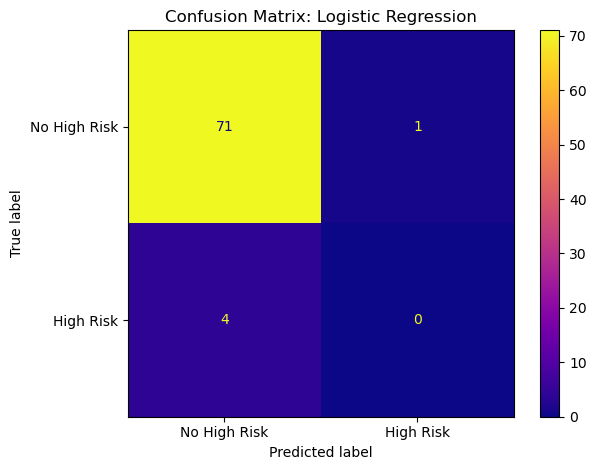

In [95]:
# Importing confusion matrix tools for evaluation
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Importing matplotlib for plotting
import matplotlib.pyplot as plt

# Computing the confusion matrix from actual and predicted values
cm_logistic = confusion_matrix(y_test, y_pred_logistic)

# Printing the confusion matrix title
print("Confusion Matrix:")

# Showing the raw confusion matrix numbers
print(cm_logistic)

# Creating a visual display object for the confusion matrix
display_cm = ConfusionMatrixDisplay(
    confusion_matrix=cm_logistic,
    display_labels=["No High Risk", "High Risk"]
)

# Plotting the confusion matrix with a plasma colormap
display_cm.plot(cmap="plasma")

# Adding a title to the chart
plt.title("Confusion Matrix: Logistic Regression")

# Adjusting the layout to fit the chart
plt.tight_layout()

# Displaying the chart
plt.show()

In [96]:
# Importing accuracy, precision, recall and F1 score metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Calculating accuracy
accuracy_logistic = accuracy_score(y_test, y_pred_logistic)

# Calculating precision
precision_logistic = precision_score(y_test, y_pred_logistic, zero_division=0)

# Calculating recall
recall_logistic = recall_score(y_test, y_pred_logistic, zero_division=0)

# Calculating F1 score
f1_logistic = f1_score(y_test, y_pred_logistic, zero_division=0)

# Printing the evaluation metrics title
print("Logistic Regression Evaluation Metrics:")

# Printing accuracy
print("Accuracy: ", round(accuracy_logistic, 4))

# Printing precision
print("Precision:", round(precision_logistic, 4))

# Printing recall
print("Recall:   ", round(recall_logistic, 4))

# Printing F1 score
print("F1 Score: ", round(f1_logistic, 4))

Logistic Regression Evaluation Metrics:
Accuracy:  0.9342
Precision: 0.0
Recall:    0.0
F1 Score:  0.0


In [97]:
# Importing classification report for detailed per-class metrics
from sklearn.metrics import classification_report

# Printing the classification report title
print("Classification Report:")

# Showing the full classification report
print(classification_report(y_test, y_pred_logistic, target_names=["No High Risk", "High Risk"], zero_division=0))

Classification Report:
              precision    recall  f1-score   support

No High Risk       0.95      0.99      0.97        72
   High Risk       0.00      0.00      0.00         4

    accuracy                           0.93        76
   macro avg       0.47      0.49      0.48        76
weighted avg       0.90      0.93      0.92        76



In [98]:
# Creating a DataFrame with actual and predicted values
classification_output_df = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred_logistic
})

# Saving the classification outputs to a CSV file
classification_output_df.to_csv(output_dir / "classification_outputs.csv", index=False)

# Confirming the file was saved
print("Classification outputs saved to:", output_dir / "classification_outputs.csv")

# Printing the output folder contents title
print("\nFiles in output folder:")

# Looping through all files in the output folder
for f in sorted(output_dir.iterdir()):
    # Printing each file name
    print(" ", f.name)

Classification outputs saved to: output\classification_outputs.csv

Files in output folder:
  classification_outputs.csv
  cleaned_dataset.csv


#### Task 2: Explanation

#### Question 1: What is the model trying to predict?

The model is trying to predict whether a customer has high investment risk or not. The target column is called High Investment Risk. It has two possible values. The value No means the customer is not considered high risk. The value Yes means the customer is considered high risk. I converted No to 0 and Yes to 1 so the model can work with numbers.

This is a supervised binary classification problem. Supervised means the training data already has the correct answers. Binary means there are only two possible output classes which are 0 and 1.

In a real business setting this prediction is useful because financial advisors can use it to identify which customers need more careful attention and more conservative investment advice.


#### Question 2: What dataset did I use?

I used the Financial Customer Investment Risk Dataset. This dataset contains information about 387 financial customers. Each row represents one customer and each column describes one characteristic of that customer.

The original dataset had 7 duplicate rows. After removing duplicates the cleaned dataset had 380 rows and 13 columns. The dataset also had missing values in 6 columns which I filled using the median for numerical columns and the most common value for categorical columns.

One important observation about this dataset is that it is heavily imbalanced. Out of 380 customers only 20 customers are labelled as high risk which is 5.3 percent of the data. The remaining 360 customers are labelled as not high risk which is 94.7 percent of the data. This imbalance has a direct impact on how well the model performs.


#### Question 3: What features and target did I select?

The target variable is High Investment Risk. This is the column I am trying to predict.

I selected 11 feature columns to use as input to the model.

1. Age: the age of the customer in years
2. Employment Status: whether the customer is full time, part time, retired, student or self employed
3. Annual Income: how much the customer earns per year in dollars
4. Investment Experience Years: how many years the customer has been investing
5. Portfolio Value: the total current value of the customer investments in dollars
6. Risk Tolerance: how the customer describes their own comfort with risk as low, medium or high
7. Number of Investment Products: how many different investment products the customer holds
8. Market Volatility Concern: a score from 1 to 5 showing how worried the customer is about market changes
9. Financial Literacy Score: a score measuring how well the customer understands financial topics
10. Advisor Contacted: whether the customer has contacted a financial advisor before
11. Previous Investment Loss: whether the customer has experienced an investment loss in the past

I did not include the Customer ID column because it is only a unique identification number assigned to each row. It does not describe any real characteristic of the customer and including it would confuse the model.


#### Question 4: What results did I obtain?

I split the dataset into a training set and a testing set. The training set had 304 rows which is 80 percent of the cleaned data. The testing set had 76 rows which is 20 percent. I used stratified splitting so both sets kept the same class proportion.

The testing set contained 72 customers labelled as No High Risk and 4 customers labelled as High Risk.

After training Logistic Regression on the training set and predicting on the testing set I obtained the following results.

Accuracy: 93.42 percent

This means 71 out of 76 predictions were correct. This number looks high but it is misleading because the dataset is imbalanced. Even a model that always predicts No High Risk would get around 94.7 percent accuracy.

Precision: 0 percent

Precision measures how many of the customers the model predicted as High Risk were actually High Risk. The model only predicted 1 customer as High Risk and that prediction was wrong. The other 75 customers were all predicted as No High Risk. This means precision is 0 percent.

Recall: 0 percent

Recall measures how many of the actual High Risk customers the model correctly identified. There were 4 real High Risk customers in the test set. The model found none of them. All 4 were predicted as No High Risk. This means recall is 0 percent.

F1 Score: 0 percent

The F1 score combines precision and recall. Since both are 0 the F1 score is also 0. This is the most honest measure of how poorly the model is performing on the important class.

Confusion Matrix breakdown:

1. True Negatives: 71 customers were correctly predicted as No High Risk
2. False Positives: 1 customer was predicted as High Risk but was actually No High Risk
3. False Negatives: 4 customers were predicted as No High Risk but were actually High Risk
4. True Positives: 0 customers were correctly predicted as High Risk

The model failed to correctly identify a single high risk customer. In summary the model learned to predict No for almost every customer because that gave it the highest accuracy on the imbalanced data.


#### Question 5: One limitation of the model or dataset

The most important limitation of this model is the severe class imbalance in the dataset. Only 20 out of 380 customers are labelled as High Risk which is 5.3 percent. The Logistic Regression model sees the No class almost all the time during training so it learns that predicting No is almost always correct. As a result it almost never predicts Yes.

This means the model has very high accuracy but completely fails at the task that actually matters which is finding the high risk customers. In a real financial setting missing a high risk customer is a much more serious mistake than incorrectly flagging a safe customer as risky.

One way to fix this limitation is to use class weighting. By setting class weight to balanced inside the Logistic Regression model the algorithm is told to treat errors on the minority class as more costly than errors on the majority class. This would push the model to actually try to find the High Risk customers instead of ignoring them.

Another way to address this is to use oversampling techniques such as SMOTE which creates new synthetic examples of the minority class to balance the training data before fitting the model.